In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Load new 70/10/20 split data
print("Loading data...")
X_train = pd.read_csv('../extracted/X_train.csv')
X_val   = pd.read_csv('../extracted/X_val.csv')
X_test  = pd.read_csv('../extracted/X_test.csv')
y_train = pd.read_csv('../extracted/y_train_binary.csv').squeeze()
y_val   = pd.read_csv('../extracted/y_val_binary.csv').squeeze()
y_test  = pd.read_csv('../extracted/y_test_binary.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train distribution: {y_train.value_counts().to_dict()}")

Loading data...
Train: (14703605, 39)
Val:   (2100516, 39)
Test:  (4201031, 39)
Train distribution: {1: 13970490, 0: 733115}


Training Random Forest...
Training time: 182.2s

=== RANDOM FOREST — VALIDATION ===
Accuracy: 0.9854
F1 Macro: 0.9232

=== RANDOM FOREST — TEST ===
Accuracy:    0.9855
F1 Weighted: 0.9855
F1 Macro:    0.9238

Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8543    0.8560    0.8551    209462
      Attack     0.9924    0.9923    0.9924   3991569

    accuracy                         0.9855   4201031
   macro avg     0.9234    0.9241    0.9238   4201031
weighted avg     0.9856    0.9855    0.9855   4201031



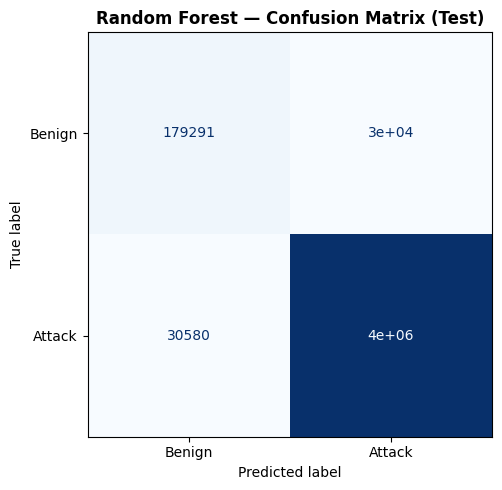

Saved: rf_confusion_matrix.png


In [7]:
# === MODEL 1: Random Forest ===
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
rf_time = time.time() - t0
print(f"Training time: {rf_time:.1f}s")

# Evaluate on validation
rf_val_pred = rf.predict(X_val)
print(f"\n=== RANDOM FOREST — VALIDATION ===")
print(f"Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")
print(f"F1 Macro: {f1_score(y_val, rf_val_pred, average='macro'):.4f}")

# Evaluate on test
rf_test_pred = rf.predict(X_test)
print(f"\n=== RANDOM FOREST — TEST ===")
print(f"Accuracy:    {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"F1 Weighted: {f1_score(y_test, rf_test_pred, average='weighted'):.4f}")
print(f"F1 Macro:    {f1_score(y_test, rf_test_pred, average='macro'):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, rf_test_pred, 
      target_names=['Benign', 'Attack'], digits=4))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: rf_confusion_matrix.png")

Training XGBoost...
Training time: 18.0s

=== XGBOOST — VALIDATION ===
Accuracy: 0.9721
F1 Macro: 0.8832

=== XGBOOST — TEST ===
Accuracy:    0.9723
F1 Weighted: 0.9751
F1 Macro:    0.8837

Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.6431    0.9979    0.7821    209462
      Attack     0.9999    0.9709    0.9852   3991569

    accuracy                         0.9723   4201031
   macro avg     0.8215    0.9844    0.8837   4201031
weighted avg     0.9821    0.9723    0.9751   4201031



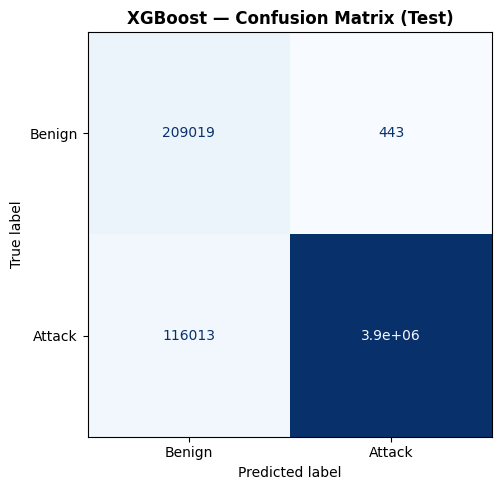

Saved: xgb_confusion_matrix.png


In [8]:
# === MODEL 2: XGBoost ===
print("Training XGBoost...")
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_time = time.time() - t0
print(f"Training time: {xgb_time:.1f}s")

# Validation
xgb_val_pred = xgb_model.predict(X_val)
print(f"\n=== XGBOOST — VALIDATION ===")
print(f"Accuracy: {accuracy_score(y_val, xgb_val_pred):.4f}")
print(f"F1 Macro: {f1_score(y_val, xgb_val_pred, average='macro'):.4f}")

# Test
xgb_test_pred = xgb_model.predict(X_test)
print(f"\n=== XGBOOST — TEST ===")
print(f"Accuracy:    {accuracy_score(y_test, xgb_test_pred):.4f}")
print(f"F1 Weighted: {f1_score(y_test, xgb_test_pred, average='weighted'):.4f}")
print(f"F1 Macro:    {f1_score(y_test, xgb_test_pred, average='macro'):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, xgb_test_pred,
      target_names=['Benign', 'Attack'], digits=4))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Confusion Matrix (Test)', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: xgb_confusion_matrix.png")

In [11]:
# === FINAL ML COMPARISON ===
results = {
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [0.9855, 0.9723],
    'F1 Weighted': [0.9855, 0.9751],
    'F1 Macro': [0.9238, 0.8837],
    'Benign Precision': [0.8543, 0.6431],
    'Benign Recall': [0.8560, 0.9979],
    'Benign F1': [0.8551, 0.7821],
    'Attack F1': [0.9924, 0.9852],
    'Val F1 Macro': [0.9232, 0.8832],
    'Test F1 Macro': [0.9238, 0.8837],
    'Train Time (s)': [182.2, 18.0]
}

results_df = pd.DataFrame(results)
results_df.to_csv('ml_baseline_results_v2.csv', index=False)
print("=== ML BASELINE RESULTS (70/10/20 split) ===")
print(results_df.to_string(index=False))
print("\nSaved: ml_baseline_results_v2.csv")

=== ML BASELINE RESULTS (70/10/20 split) ===
        Model  Accuracy  F1 Weighted  F1 Macro  Benign Precision  Benign Recall  Benign F1  Attack F1  Val F1 Macro  Test F1 Macro  Train Time (s)
Random Forest    0.9855       0.9855    0.9238            0.8543         0.8560     0.8551     0.9924        0.9232         0.9238           182.2
      XGBoost    0.9723       0.9751    0.8837            0.6431         0.9979     0.7821     0.9852        0.8832         0.8837            18.0

Saved: ml_baseline_results_v2.csv


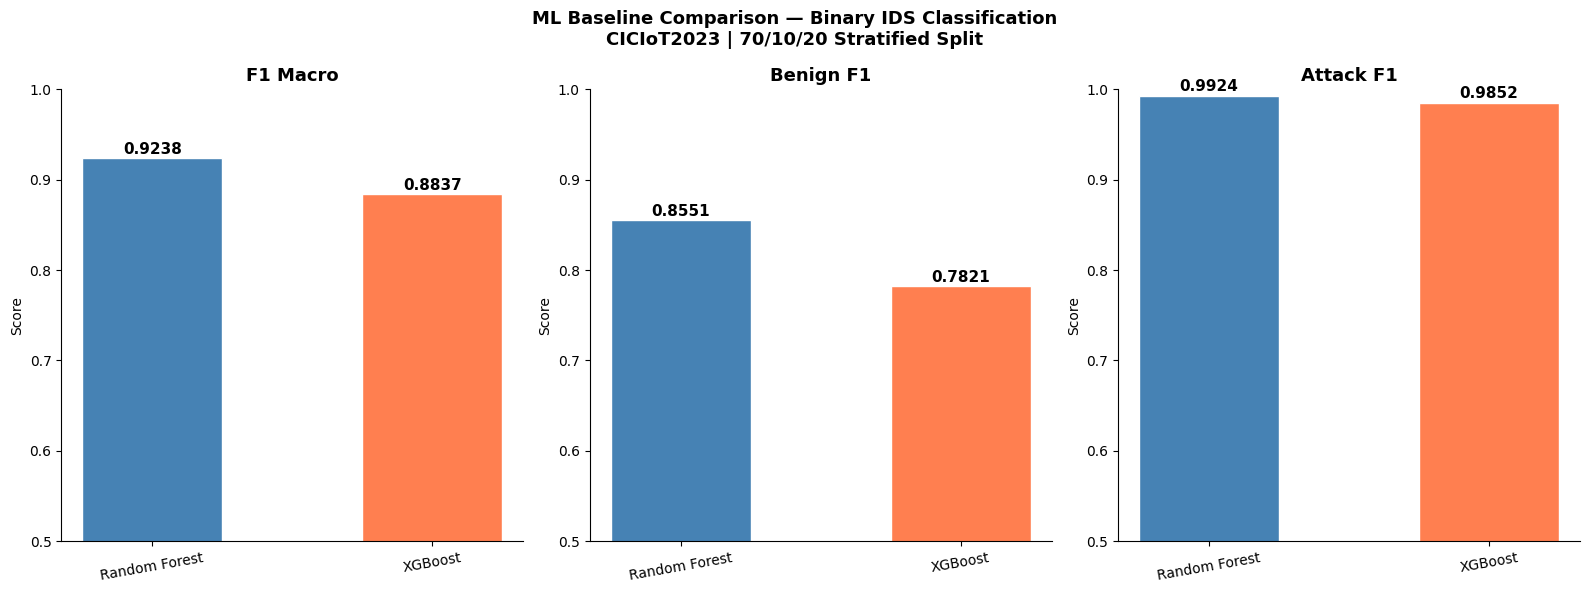

Saved: ml_baseline_comparison_v2.png


In [12]:
# === COMPARISON PLOTS ===
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = ['F1 Macro', 'Benign F1', 'Attack F1']
values = {
    'F1 Macro':  [0.9238, 0.8837],
    'Benign F1': [0.8551, 0.7821],
    'Attack F1': [0.9924, 0.9852]
}
colors = ['steelblue', 'coral']
models = ['Random Forest', 'XGBoost']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(models, values[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, values[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('ML Baseline Comparison — Binary IDS Classification\nCICIoT2023 | 70/10/20 Stratified Split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_baseline_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ml_baseline_comparison_v2.png")

In [13]:
import pickle

# Save trained models
pickle.dump(rf, open('../extracted/rf_model.pkl', 'wb'))
pickle.dump(xgb_model, open('../extracted/xgb_model.pkl', 'wb'))
print("Saved: rf_model.pkl")
print("Saved: xgb_model.pkl")

Saved: rf_model.pkl
Saved: xgb_model.pkl
